In [15]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



# Make plots for Griffith & McDermott ARO 2023 poster: Human-like Attentional Selection Emerges as a Solution to the Cocktail Party Problem

### Plots to include:
* [Demo waves and cochlaegrams](#cochleagrams)
* [Attentive listening task:](#Attentive_listening_task)
    * Model & human word correct with 1-talker 4-talker & stationary noise distractors 
    * Model & human confusions with 1-talker distractor
* [Target-distractor sex similarity:](#sex_similarity)
    * Model & human word correct with same/different flags (rows for model & human)
    * add confusions as separate panel, same legend & arrangement 
* [Harmonic vs inharmonic speech from model](#harmonicity)
* [Attenntional gais](#gains)
* [Stream correlations for several architectures on same plot](#corrs)

In [2]:
plot_out_dir = Path('/om2/user/imgriff/projects/Auditory-Attention/ARO_2023_figs/')

<a id='cochleagrams'></a>

## Demo cochleagrams & waves

In [3]:
import sys 
sys.path.append('../')
from corpus.jsinV3_attn_multi_talker_w_audioset import jsinV3_attn_multi_talker_w_audioset
import matplotlib
import src.audio_transforms as at
import yaml 

path = Path('../config/attentional_cue/attn_cue_match_target_speech_and_noise.yaml')
config = yaml.load(open(path, 'r'), Loader=yaml.FullLoader)

model_name = path.stem
model_name


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'attn_cue_match_target_speech_and_noise'

In [8]:
import src.audio_transforms as at
audio_config = config['data']['audio']

audio_transforms = at.AudioCompose([
    at.AudioToTensor(),
    at.RMSNormalizeForegroundAndBackground(rms_level=0.1), # normalize so all signals at same level pre-mix
    at.CombineWithRandomDBSNR(low_snr=config['noise_kwargs']['low_snr'],
                               high_snr=config['noise_kwargs']['high_snr']),
    at.RMSNormalizeForegroundAndBackground(rms_level=0.1), # set cue to same level as target 
    at.UnsqueezeAudio(dim=0),
#     aat.AudioToAudioRepresentation(**audio_config)
])
# these transforms take foreground, background as input 
bg_combine_transforms = at.AudioCompose([
                at.AudioToTensor(),
                at.CombineWithRandomDBSNR(low_snr=config['noise_kwargs']['low_snr'],
                                          high_snr=config['noise_kwargs']['high_snr']),
                at.RMSNormalizeForegroundAndBackground(rms_level=0.1)
            ])

coch_transform = at.AudioToAudioRepresentation(**audio_config)


# del config['data']['corpus']['n_talkers']
# del config['data']['corpus']['with_audioset']


dataset = jsinV3_attn_multi_talker_w_audioset(**config['data']['corpus'],
#                                           train=False,
                                          mode='val',
                                          n_talkers=1,
                                          with_audioset=False,
                                          transform=[audio_transforms, bg_combine_transforms],
                                          demo=True)


foreground, background, mixture, fg_cue, fg_target = dataset[0]

mixture_coch, _ = coch_transform(mixture, None)
cue_coch, _ = coch_transform(fg_cue, None)

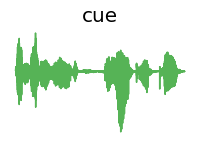

In [26]:
fontsize = 20




plt.figure(figsize=(3.33, 2))
# plt.subplot(2,2,1)
plt.plot(fg_cue.squeeze(), c='tab:green', alpha=0.8)
plt.title('cue', fontsize=fontsize)
plt.axis('off');
# plt.show()

out_name = plot_out_dir / 'cue_wavs_green.svg'
plt.savefig(out_name, bbox_inches='tight')

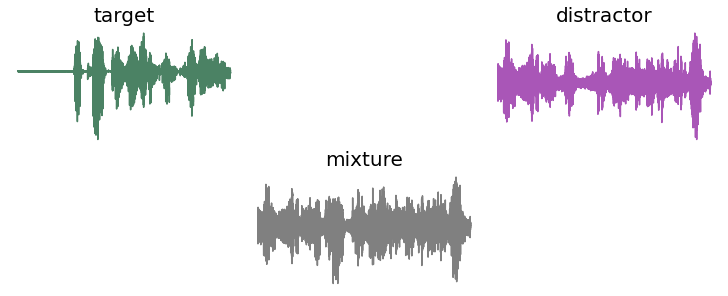

In [30]:
fontsize=20

palette = sns.diverging_palette(145, 300,n=2, s=60, as_cmap=False)



mosaic = """a.b
            .c."""
fig, axd = plt.subplot_mosaic(mosaic,
                              figsize=(10, 4), layout="constrained",
                             )


axd['a'].plot(foreground.squeeze(), c=palette[0])
axd['a'].set_title('target', fontsize=fontsize)
axd['a'].axis('off');

axd['b'].plot(background.squeeze(), c=palette[1])
axd['b'].set_title('distractor', fontsize=fontsize)
axd['b'].axis('off');

axd['c'].plot(mixture.squeeze(), 'grey')
axd['c'].set_title('mixture', fontsize=fontsize)
axd['c'].axis('off');

out_name = plot_out_dir / 'mix_wavs_g_p.svg'
plt.savefig(out_name, bbox_inches='tight')

In [ ]:
plt.figure(figsize=(4,2))
fontsize=16
plt.imshow(cue_coch.squeeze(), aspect='auto', vmin=cue_coch.min(), vmax=cue_coch.max() * 0.5, cmap=cm.Blues)
# plt.axis('off')
plt.yticks([0,39], ['8K', '0'], fontsize=fontsize-2)
plt.ylabel('frequency (Hz)', fontsize=fontsize)
plt.xticks([0,16000],[0, 2], fontsize=fontsize-2)
plt.xlabel('time (s)', fontsize=fontsize)
plt.title('cue', fontsize=fontsize)
# plt.axis('off')

# out_name = plot_out_dir / 'cue_cochleagram.svg'
# plt.savefig(out_name, bbox_inches='tight')

In [ ]:
plt.figure(figsize=(4,2))
fontsize=16
plt.imshow(mixture_coch.squeeze(), aspect='auto', 
           vmin=mixture_coch.min(),vmax=mixture_coch.max()*.5,
           cmap=cm.Blues)
# plt.axis('off')
# plt.yticks([0,39], ['10K', '0'], fontsize=fontsize-2)
# plt.ylabel('frequency (Hz)', fontsize=fontsize)
# plt.xticks([0,16000],[0, 2], fontsize=fontsize-2)
# plt.xlabel('time (s)', fontsize=fontsize)
plt.title('mixture', fontsize=fontsize)

plt.axis('off')

# out_name = plot_out_dir / 'mixture_cochleagram.svg'
# plt.savefig(out_name, bbox_inches='tight')

# Make EG sigmiod function 

Text(0, 0.5, 'Gain')

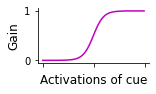

In [3]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

fig, axs = plt.subplots(1, figsize=(2,1))
x = np.linspace(-10,10,100)

sns.despine()
axs.plot(sigmoid(x), 'm')
axs.set_xticklabels('');
plt.xlabel('Activations of cue', fontsize=12)
plt.ylabel('Gain', fontsize=12)


# plt.savefig(plot_out_dir / 'sigmoid.svg',  format="svg", bbox_inches='tight')

### Get TIMIT pandas for metadata

In [6]:
df_paths = list(Path('/om2/user/imgriff/datasets/timit/attn_task_dataframes_mturk/').glob('*dataset*.pdpkl'))
# df_path = df_paths[:] # want sets 1 & 2 for now

In [7]:
# df_paths

In [8]:
meta_df = []
for path in df_paths:
    df = pd.read_pickle(path)
    df['stim_subset'] = int(re.search('dataset_(-?\d+)', path.stem).group(0).split('_')[-1])
    meta_df.append(df)
meta_df = pd.concat(meta_df, axis=0)

In [9]:
# pd.concat(meta_df, axis=0)

### Get experimental results csv

In [10]:
results_path = Path('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/')
# results_df = pd.read_csv(results_path / 'Batch_367265_batch_results.csv')

# results_files = [file for file in results_path.glob("*.csv") if file.stem != "Batch_367574_batch_results" ]

results_files = list(results_path.glob("*.csv"))

In [11]:
results_files

[PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4926170_batch_results.csv'),
 PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4928442_batch_results.csv'),
 PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4934342_batch_results.csv'),
 PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4934809_batch_results.csv'),
 PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4941864_batch_results.csv')]

In [12]:
## Get condition map to translate stimuli file names to relevant condition variables
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
class_map = word_and_speaker_encodings['word_idx_to_word']

# file_name = truth['stim_file_name'][100]

def file_name_to_labels(file_name):
    file = Path(file_name)
    word = re.search('word_(-?\d+)', file.stem).group(0).split('_')[-1]
    word = class_map[int(word)]
    orig_df_ix = re.search('stim_(-?\d+)', file.stem).group(0).split('_')[-1]
    orig_dataset_ix = re.search('set_(-?\d+)', file.stem).group(0).split('_')[-1]
    if 'ssn' in file.stem:
        cond = 'ssn'
        speaker_sex = 'ssn'
    elif "catch_trial" not in file.as_posix():
        cond = re.search('cond_(-?\d+)', file.stem).group(0).split('_')[-1]
        speaker_sex = re.search('speaker_(\w)', file.stem).group(0).split('_')[-1]
    if "catch_trial" in file.as_posix():
        snr = 'clean'
        cond = 'catch_trial'
        speaker_sex = re.search('speaker_(\w)', file.stem).group(0).split('_')[-1]
    else:
        snr = re.search('snr_(-?\d+)', file.stem).group(0).split('_')[-1]
    return int(orig_dataset_ix), word, snr, cond, speaker_sex, int(orig_df_ix)


In [13]:
# Get data from each batch file 
dfs = []
for ix, file in enumerate(results_files):
    df = pd.read_csv(file)
    df = df.rename(index={ix:f'p{ix}' for ix in range(len(df))})

    truth = df[[col for col in list(df) if 'Audio_Exp' in col]]
    truth = truth.T
    truth = truth.rename(index={ix:f"trial {ix.split('_')[-1]}" for ix in truth.index})
    truth = truth.dropna(axis='columns')
    truth = pd.melt(truth.reset_index(), 
                    id_vars=['index'], 
                    var_name = 'participant',
                    value_name = 'stim_path',
                    ignore_index=False)

    responses = df[[col for col in list(df) if 'Resp_Exp' in col]]
    responses = responses.T
    responses = responses.rename(columns={0:"guessed_word"}, index={ix:f"trial {ix.split('_')[-1]}" for ix in responses.index})
    responses = responses.dropna(axis='columns')

    responses = pd.melt(responses.reset_index(), 
                    id_vars=['index'], 
                    var_name = 'participant',
                    value_name = 'guessed_word',
                    ignore_index=False)

    results = responses.merge(truth, on=['index', 'participant'])
    results['participant'] = results['participant'] + f'_{ix}' 

    results['stim_subset'], results['true_word'], results['snr'], results['distractor_condition'], results['target_sex'], results['orig_df_ix'] = zip(*results['stim_path'].map(file_name_to_labels))

    ## Get distractor information from dfs 
    for stim_subset in results.stim_subset.unique():
        # get ixs for samples with this dataset
        result_ixs = np.where(results.stim_subset == stim_subset)[0]
        # get matching metadata
        meta_subset = meta_df[meta_df.stim_subset == stim_subset]
        results.loc[result_ixs, 'distractor_words'] = meta_subset.loc[results.loc[result_ixs, 'orig_df_ix'], ['distractor_words']].values
        results.loc[result_ixs, 'distractor_sex'] = meta_subset.loc[results.loc[result_ixs, 'orig_df_ix'], ['distractor_sex']].values
    dfs.append(results)
results = pd.concat(dfs)
print(results.shape)


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from r

(9100, 12)


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from r

#### Process results csv to plotting format

In [14]:
len(results.participant.unique())

50

In [15]:
results['accuracy'] = (results['guessed_word'] == results['true_word']).astype('int')

In [16]:
get_confusion = lambda row: int(row.guessed_word in row.distractor_words)

results['confusions'] = results[['guessed_word', 'distractor_words']].apply(get_confusion, axis=1)

In [17]:
catch_trial_particiapnt_performance = results[results.distractor_condition == 'catch_trial'].groupby('participant').accuracy.mean()


In [18]:
len(catch_trial_particiapnt_performance) # catch trial performance for each participant 

50

In [19]:
# filter out bad performers on catch trials  
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance > 9/12].index

In [20]:
good_results = results[results.participant.isin(good_participants)]

## Get model results all subsets

In [21]:
parent_path = Path('/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_attn_task_all_targets_MultiDistractorAttnCNN/version_0/')
timit_results = list(parent_path.rglob("*.csv"))

In [22]:
timit_results

[PosixPath('/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_attn_task_all_targets_MultiDistractorAttnCNN/version_0/metrics.csv')]

In [23]:
model_results = pd.read_csv(timit_results[0])

In [24]:
model_results.shape

(41492, 3)

In [25]:
model_results.head()

,ACC/test_fg_acc,pred_word_ix,step
0,1.0,552.0,0
1,0.0,392.0,1
2,0.0,689.0,2
3,1.0,659.0,3
4,0.0,90.0,4


In [26]:
model_results = model_results.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, 
                      index={ix:f"trial {ix}" for ix in model_results.index})
model_results['pred_word_ix'] = model_results['pred_word_ix'].astype('int') 

In [27]:
### import parent model stim df
out_path = Path('/om2/user/imgriff/datasets/timit/attn_task_dataframes/')

model_meta_df = pd.read_pickle(out_path / 'timit_attn_stim_for_model_all_targets_metadata_only.pdpkl')

In [28]:
model_meta_df = model_meta_df.loc[:,~model_meta_df.columns.str.contains('signal')]

In [29]:
model_results['guessed_word'] = model_results['pred_word_ix'].map(class_map)

### Get metadata from timit df 
model_results['true_word'] = model_meta_df.loc[model_results.orig_df_ix, ['word']].values
model_results['distractor_words'] = model_meta_df.loc[model_results.orig_df_ix, ['distractor_words']].values
model_results['distractor_sex'] = model_meta_df.loc[model_results.orig_df_ix, ['distractor_sex']].values
model_results['snr'] = model_meta_df.loc[model_results.orig_df_ix, ['snrs']].values.astype('str')
model_results['distractor_condition'] = model_meta_df.loc[model_results.orig_df_ix, ['distractor_conditions']].values.astype('str')
model_results['target_sex'] = model_meta_df.loc[model_results.orig_df_ix, ['speaker_sex']].values


In [30]:
model_results['confusions'] = model_results[['guessed_word', 'distractor_words']].apply(get_confusion, axis=1)

In [31]:
model_results['subject'] = 'model'
good_results['subject'] = 'human'

/tmp/ipykernel_48228/3491488986.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_results['subject'] = 'human'


In [32]:
all_results = pd.concat([good_results, model_results])

<a id='Attentive_listening_task'></a>
# Attentive listening task plots

In [33]:
# set ssn to noise for plots 
all_results = all_results.replace('ssn', 'noise', regex=True)

In [56]:
turk_results = all_results[all_results['subject'] == 'human']

turk_summary_df = (turk_results.groupby(["snr", 'participant', "distractor_condition"])
                     .accuracy
                     .agg(["mean"])
                     .reset_index())



turk_conf_df = (turk_results.groupby(["snr", 'participant', "distractor_condition"])
                     .confusions
                     .agg(["mean"])
                     .reset_index())




In [57]:
turk_summary_df.head()

,snr,participant,distractor_condition,mean
0,-3,p12_1,1 talker,0.8
1,-3,p12_1,2,0.3
2,-3,p12_1,4 talker,0.3
3,-3,p12_1,noise,0.4
4,-3,p18_1,1 talker,0.5


## Summary figure for grant 

In [58]:
## Process for confusions and sex comparisons

## map male/female to same/different 


def remap_sex_strs(target_sex, distractors):
    if isinstance(distractors,float):
        return distractors
    if distractors == 'noise':
        return distractors 
    same_diff = ''.join(['s' if char == target_sex else 'd' for char in distractors])
    return same_diff

all_results['distractor_type'] = all_results[['target_sex',
                                              'distractor_sex']].apply(lambda x: remap_sex_strs(x.target_sex, x.distractor_sex),
                                                    axis=1)


In [59]:
## Make distractor hue colors 

# distractor_hue_order = [cond for cond in results.distractor_sex.unique().astype('str')
#                         if 'm' in cond or 'f' in cond]

# distractor_hue_order = sorted(distractor_hue_order, key=lambda x: len(x))

from itertools import groupby


distractor_hue_order = ['s', 'd', 'ss', 'sd', 'dd', 'ssss', 'sssd', 'ssdd', 'sddd', 'dddd']

grouped_distractors = [list(set(items)) for length, items in groupby(distractor_hue_order, key=len)]
grouped_distractors = [sorted(elems) for elems in grouped_distractors]

distractor_palette = {}
print(grouped_distractors)

color_palettes = [sns.diverging_palette(220, 20, center="dark", n=2, as_cmap=False),
                sns.diverging_palette(145, 300, center="dark", s=60, n=3, as_cmap=False),
                sns.color_palette("coolwarm", n_colors=5, as_cmap=False)]


for g_ix, group in enumerate(grouped_distractors):
    n_in_group = len(group)
    for d_ix, dist in enumerate(group):
        distractor_palette[dist] = color_palettes[g_ix][d_ix]


distractor_palette['ssdd'] = distractor_palette['sd']

# skip 2 distractor condition
sex_distractor_palette = {k:v for k,v in distractor_palette.items() if len(k) !=2}
sex_distractor_hue_order = ['s', 'd', 'ssss', 'sssd', 'ssdd', 'sddd', 'dddd']


[['d', 's'], ['dd', 'sd', 'ss'], ['dddd', 'sddd', 'ssdd', 'sssd', 'ssss']]


In [60]:
## Get stats for sex similarity plots:

turk_results = all_results[all_results['subject'] == 'human']

turk_by_sex_accuracy_df = (turk_results.groupby(["snr", 'participant',
                                         "distractor_condition", "distractor_type"])
                     .accuracy
                     .agg(["mean"])
                     .reset_index())

turk_by_sex_accuracy_df.rename(columns={'mean':'accuracy'}, inplace=True)
turk_by_sex_confusion_df = (turk_results.groupby(["snr", 'participant',
                                         "distractor_condition", "distractor_type"])
                     .confusions
                     .agg(["mean"])
                     .reset_index())
turk_by_sex_confusion_df.rename(columns={'mean':'confusions'}, inplace=True)




# turk_summary_df = (turk_results.groupby(["snr", 'participant',
#                                          "distractor_condition", "distractor_sex", 'target_sex'])
#                      .accuracy
#                      .agg(["mean"])
#                      .reset_index())

turk_by_sex_accuracy_df.head()

,snr,participant,distractor_condition,distractor_type,accuracy
0,-3,p12_1,1 talker,d,1.0
1,-3,p12_1,1 talker,s,0.6
2,-3,p12_1,2,dd,0.0
3,-3,p12_1,2,ds,0.0
4,-3,p12_1,2,sd,1.0


In [61]:
sex_acc = pd.merge(turk_by_sex_accuracy_df, all_results[all_results.subject=='model'], 
        on=['snr', 'participant', 'distractor_condition', 'distractor_type',
       'accuracy'],

        how='outer')
sex_acc['subject'][~sex_acc.participant.isna()] = 'human'

/tmp/ipykernel_48228/2228803891.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sex_acc['subject'][~sex_acc.participant.isna()] = 'human'


In [62]:
sex_name_update = {'s': "Same", 'd':'Different'}
sex_acc['distractor_type'] = sex_acc['distractor_type'].replace(sex_name_update)
turk_by_sex_confusion_df['distractor_type'] = turk_by_sex_confusion_df['distractor_type'].replace(sex_name_update)
sex_distractor_palette = {(sex_name_update[k] if k in sex_name_update.keys() else k):v 
                          for k,v in sex_distractor_palette.items()}

In [63]:
dist_name_update = {'1': "1 talker", '4':'4 talker', 'noise':'noise'}
turk_summary_df['distractor_condition'] = turk_summary_df['distractor_condition'].replace(dist_name_update)
all_results['distractor_condition'] = all_results['distractor_condition'].replace(dist_name_update)

In [68]:
sex_acc[sex_acc['subject'] == 'human']

,snr,participant,distractor_condition,distractor_type,accuracy,index,guessed_word,stim_path,stim_subset,true_word,target_sex,orig_df_ix,distractor_words,distractor_sex,confusions,subject,pred_word_ix
0,-3,p12_1,1 talker,Different,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,human,NaN
1,-3,p12_1,1 talker,Same,0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,human,NaN
2,-3,p12_1,2,dd,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,human,NaN
3,-3,p12_1,2,ds,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,human,NaN
4,-3,p12_1,2,sd,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,human,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1232,3,p9_0,4 talker,dddd,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,human,NaN
1233,3,p9_0,4 talker,ddss,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,human,NaN
1234,3,p9_0,4 talker,ssdd,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,human,NaN
1235,3,p9_0,4 talker,ssss,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,human,NaN


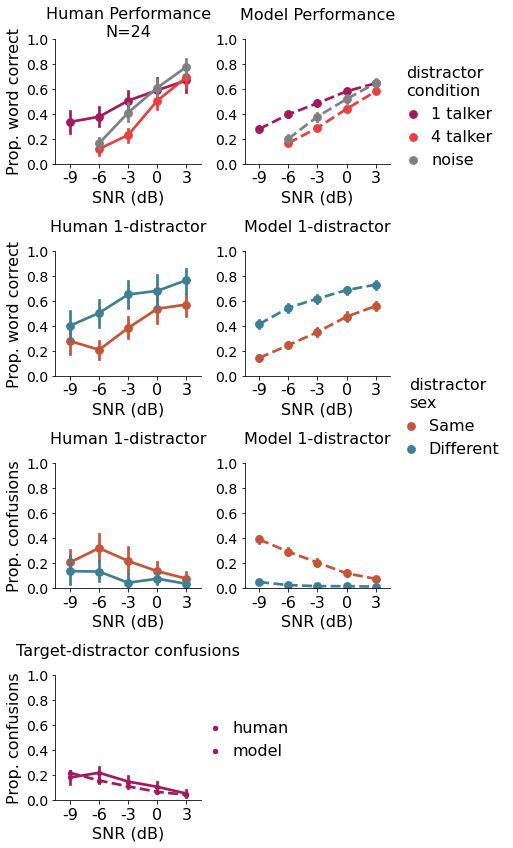

In [117]:
snr_order = ['-9', '-6', '-3', '0', '3' ]
hue_order = ['1 talker', '4 talker', 'noise']
sex_distractor_hue_order = ['Same', 'Different']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 16

distractor_cmap = sns.color_palette("rocket", 4, as_cmap=False)
distractor_palette = {cond:distractor_cmap[ix+1] for ix, cond in enumerate(hue_order[:3])}
distractor_palette['noise'] = 'grey'

n_participants = len(turk_summary_df.participant.unique())


fig, axs = plt.subplots(4,2, figsize=(6,14), sharey=False, sharex=False)
axs = axs.ravel()

# attn 
g = sns.pointplot( data=turk_summary_df, x = 'snr', y = 'mean', order=snr_order,
            hue ='distractor_condition',  error='sem', 
            hue_order=hue_order, palette=distractor_palette, 
            ax=axs[0])

g1 = sns.pointplot( data=all_results[all_results.subject=='model'], x = 'snr', y = 'accuracy', order=snr_order,
            hue ='distractor_condition', linestyles='--',
            hue_order=hue_order, palette=distractor_palette,
             errorbar=('ci', 95), n_boot=1000, seed=1,
               ax=axs[1])

# same diff sex acc
# 1 distractor 
g2 = sns.pointplot( data=sex_acc[(sex_acc.subject=='human') & (sex_acc.distractor_condition=='1 talker')],
              x = 'snr', y = 'accuracy', order=snr_order,
            hue ='distractor_type',  error='sem', 
            hue_order=sex_distractor_hue_order, palette=sex_distractor_palette, 
            ax=axs[2])

g3 = sns.pointplot( data=sex_acc[(sex_acc.subject=='model') & (sex_acc.distractor_condition=='1 talker')], 
                   x = 'snr', y = 'accuracy', order=snr_order,
            hue ='distractor_type', linestyles='--',
            hue_order=sex_distractor_hue_order, palette=sex_distractor_palette,
             errorbar=('ci', 95), n_boot=1000, seed=1,
               ax=axs[3])


# same diff sex confs 
g4 = sns.pointplot( data=turk_by_sex_confusion_df[turk_by_sex_confusion_df['distractor_condition']=='1 talker'],
              x = 'snr', y = 'confusions', order=snr_order,
            hue ='distractor_type',  error='sem', 
            hue_order=sex_distractor_hue_order, palette=sex_distractor_palette, 
            ax=axs[4])

g5 = sns.pointplot( data=sex_acc[(sex_acc.subject=='model') & (sex_acc.distractor_condition=='1 talker')], 
                   x = 'snr', y = 'confusions', order=snr_order,
            hue ='distractor_type', linestyles='--',
            hue_order=sex_distractor_hue_order, palette=sex_distractor_palette,
             errorbar=('ci', 95), n_boot=1000, seed=1,
               ax=axs[5])


g6 = sns.pointplot( data=all_results[all_results.distractor_condition == '1 talker'],
                  x = 'snr', y = 'confusions', order=snr_order,
            hue ='subject', height=4, linestyles=['-', '--'],  markers=['.','.'],
            palette=[distractor_palette['1 talker']] * 2,
            ax=axs[6])





# attn word rec
axs[0].set_title(f"Human Performance\nN={n_participants}",fontsize=fontsize, pad = -20)
axs[1].set_title("Model Performance", fontsize=fontsize, pad = 20)

axs[0].set_ylabel("Prop. word correct", fontsize=fontsize,)# weight='bold')
axs[1].set_ylabel("", fontsize=fontsize)

# same/diff sex word rec

axs[2].set_title("Human 1-distractor", fontsize=fontsize, pad = 20)
axs[3].set_title("Model 1-distractor", fontsize=fontsize, pad = 20)

axs[2].set_ylabel("Prop. word correct", fontsize=fontsize,)# weight='bold')
axs[3].set_ylabel("", fontsize=fontsize)

# same/diff sex confusions
axs[4].set_title("Human 1-distractor", fontsize=fontsize, pad = 20)
axs[5].set_title("Model 1-distractor", fontsize=fontsize, pad = 20)

axs[4].set_ylabel("Prop. confusions", fontsize=fontsize,)# weight='bold')
axs[5].set_ylabel("", fontsize=fontsize)

# model human confs overlaid 
axs[6].set_title("Target-distractor confusions", fontsize=fontsize, pad = 20)
axs[6].set_ylabel("Prop. confusions", fontsize=fontsize,)# weight='bold')

# set common x label
np.vectorize(lambda x: x.set_xlabel("SNR (dB)", fontsize=fontsize))(axs)

# set x ticks 
g.set_xticklabels(snr_order, size=fontsize)
g1.set_xticklabels(snr_order, size=fontsize)
g2.set_xticklabels(snr_order, size=fontsize)
g3.set_xticklabels(snr_order, size=fontsize)
g4.set_xticklabels(snr_order, size=fontsize)
g5.set_xticklabels(snr_order, size=fontsize)
g6.set_xticklabels(snr_order, size=fontsize)


sns.despine()



# axs[0].get_legend().remove()
axs[0].get_legend().remove()
axs[2].get_legend().remove()
axs[4].get_legend().remove()
axs[5].get_legend().remove()

axs[0].set_ylim(0,1)
axs[1].set_ylim(0,1)
axs[2].set_ylim(0,1)
axs[3].set_ylim(0,1)
axs[4].set_ylim(0,1)
axs[5].set_ylim(0,1)
axs[6].set_ylim(0,1)

axs[7].axis('off')

for ax in axs:
    for label in ax.get_yticklabels():
#     label.set_fontproperties(font_prop)
        label.set_fontsize(fontsize-2)


plt.subplots_adjust(wspace=0.3,
                    hspace=0.7)


sns.move_legend(g1, title='distractor\ncondition', 
                loc="best", bbox_to_anchor=(1.8, 0.9),
                handletextpad=0.1,
                frameon=False, title_size=fontsize, fontsize=fontsize)

sns.move_legend(g3, title='distractor\nsex', 
                loc="best", bbox_to_anchor=(1.85, 0.1),
                handletextpad=0.1,
                frameon=False, title_size=fontsize, fontsize=fontsize)


sns.move_legend(g6, title='', 
                loc="best", bbox_to_anchor=(1.7, 0.75),
                handletextpad=0.1,
                frameon=False, title_size=fontsize, fontsize=fontsize)


# plt.ylim(0,1)
# fig.subplots_adjust(top=0.7) # adjust the Figure in rp
# fig.suptitle('Attentive listening task', size=fontsize)
# plt.tight_layout()
plt.savefig(plot_out_dir / 'attentive_listening_task.pdf', bbox_inches='tight')
plt.savefig(plot_out_dir / 'attentive_listening_task.svg', bbox_inches='tight',  format="svg")

<a id='harmonicity'></a>

# Harmonic v inharmonic 

### Get results from jitter_fn rendered harmonic speech 

In [122]:

parent_path = Path('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_harmonic_speech_jitter_render_attn_task_0dB_SNR_all_targets_MultiDistractorAttnCNN_-20_to_20dB/version_0/')
harmonic_file = parent_path.rglob("*.csv")
harmonic_results = pd.read_csv(next(harmonic_file))

# For clean, use version_1 for Harmonic speech generated with shift f0 function
# For clean, use version_2 for Harmonic speech generated with STRAIGHT resynth via - StraightDummySynth.m

clean_path = Path('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_harmonic_speech_jitter_render_attn_task_clean_all_targets_MultiDistractorAttnCNN_-20_to_20dB/version_0/')
clean_harmonic_file = clean_path.rglob("*.csv")
clean_harmonic_results = pd.read_csv(next(clean_harmonic_file))

harmonic_results = harmonic_results.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, 
                      index={ix:f"trial {ix}" for ix in harmonic_results.index})
harmonic_results['pred_word_ix'] = harmonic_results['pred_word_ix'].astype('int') 

clean_harmonic_results = clean_harmonic_results.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, 
                      index={ix:f"trial {ix}" for ix in clean_harmonic_results.index})
clean_harmonic_results['pred_word_ix'] = clean_harmonic_results['pred_word_ix'].astype('int') 


### Get metadata for harmonic stimuli

In [204]:
### import parent model stim df
out_path = Path('/om2/user/imgriff/datasets/timit/harmonic_timit/')

harmonic_meta_data = pd.read_pickle(out_path / 'all_targets_harmonic_single_distractor_0dB_SNR_jitter_fn_render.pdpkl')

In [205]:
harmonic_results['guessed_word'] = harmonic_results['pred_word_ix'].map(class_map)

### Get metadata from timit df 
harmonic_results['true_word'] = harmonic_meta_data.loc[harmonic_results.orig_df_ix, ['word']].values
harmonic_results['distractor_words'] = harmonic_meta_data.loc[harmonic_results.orig_df_ix, ['distractor_words']].values
harmonic_results['distractor_sex'] = harmonic_meta_data.loc[harmonic_results.orig_df_ix, ['distractor_sex']].values
harmonic_results['snr'] = harmonic_meta_data.loc[harmonic_results.orig_df_ix, ['snrs']].values.astype('str')
harmonic_results['distractor_condition'] = harmonic_meta_data.loc[harmonic_results.orig_df_ix, ['distractor_conditions']].values.astype('str')
harmonic_results['target_sex'] = harmonic_meta_data.loc[harmonic_results.orig_df_ix, ['speaker_sex']].values

harmonic_results['distractor_condition'] = 'Harmonic'

clean_harmonic_results['guessed_word'] = clean_harmonic_results['pred_word_ix'].map(class_map)

### Get metadata from timit df 
clean_harmonic_results['true_word'] = harmonic_meta_data.loc[clean_harmonic_results.orig_df_ix, ['word']].values
clean_harmonic_results['target_sex'] = harmonic_meta_data.loc[clean_harmonic_results.orig_df_ix, ['speaker_sex']].values

clean_harmonic_results['distractor_condition'] = 'Harmonic Clean'


### Get Inharmonic Results

In [206]:
parent_path = Path('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_inharmonic_speech_attn_task_0dB_SNR_all_targets_MultiDistractorAttnCNN_-20_to_20dB/version_0/')
inharm_file = parent_path.rglob("*.csv")
inharm_results = pd.read_csv(next(inharm_file))

clean_inharm_path = Path('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/')
clean_inharm_path = clean_inharm_path / 'TIMIT_inharmonic_speech_attn_task_clean_all_targets_MultiDistractorAttnCNN_-20_to_20dB/version_0/'

clean_inharm_path = clean_inharm_path.rglob('*.csv')
clean_inharm_results = pd.read_csv(next(clean_inharm_path))

clean_inharm_results = clean_inharm_results.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, 
                      index={ix:f"trial {ix}" for ix in harmonic_results.index})
clean_inharm_results['pred_word_ix'] = clean_inharm_results['pred_word_ix'].astype('int') 

inharm_results = inharm_results.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, 
                      index={ix:f"trial {ix}" for ix in harmonic_results.index})
inharm_results['pred_word_ix'] = inharm_results['pred_word_ix'].astype('int') 

In [207]:
### import parent model stim df
out_path = Path('/om2/user/imgriff/datasets/timit/inharmonic_timit/')

inharm_meta_data = pd.read_pickle(out_path / 'all_targets_inharmonic_single_distractor_0dB_SNR.pdpkl')

In [208]:
clean_inharm_results['guessed_word'] = clean_inharm_results['pred_word_ix'].map(class_map)

### Get metadata from timit df 
clean_inharm_results['true_word'] = inharm_meta_data.loc[clean_inharm_results.orig_df_ix, ['word']].values
clean_inharm_results['target_sex'] = inharm_meta_data.loc[clean_inharm_results.orig_df_ix, ['speaker_sex']].values



In [209]:
clean_inharm_results['distractor_condition'] = 'Inharmonic \n (0.3 jitter) Clean'

In [210]:
inharm_results['guessed_word'] = inharm_results['pred_word_ix'].map(class_map)

### Get metadata from timit df 
inharm_results['true_word'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['word']].values
inharm_results['distractor_words'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['distractor_words']].values
inharm_results['distractor_sex'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['distractor_sex']].values
inharm_results['snr'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['snrs']].values.astype('str')
inharm_results['distractor_condition'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['distractor_conditions']].values.astype('str')
inharm_results['target_sex'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['speaker_sex']].values



In [211]:
inharm_results['distractor_condition'] = 'Inharmonic \n (0.3 jitter)'

In [212]:
## combine_dfs 

harmonicity_results = pd.concat([harmonic_results,
                         clean_harmonic_results,
                         inharm_results,
                         clean_inharm_results], ignore_index=True)

get_confusion = lambda row: int(row.guessed_word in row.distractor_words) if not isinstance(row.distractor_words, float) else row.distractor_words

harmonicity_results['confusion'] = harmonicity_results[['guessed_word', 'distractor_words']].apply(get_confusion, axis=1)


In [213]:
spch_rslts = pd.melt(harmonicity_results, id_vars=['distractor_condition'],

        value_vars=['accuracy', 'confusion'],
        value_name = 'hits',
        var_name = 'attended_stream')

spch_rslts['attended_stream'][spch_rslts['attended_stream'] == 'accuracy'] = "Cued stream"
spch_rslts['attended_stream'][spch_rslts['attended_stream'] == 'confusion']= "Uncued stream"

spch_rslts['attended_stream'][spch_rslts['distractor_condition'].str.contains('Clean')] = "Single sentence"
spch_rslts['distractor_condition'] = spch_rslts['distractor_condition'].apply(lambda x: x.replace(' Clean', ''))


/tmp/ipykernel_3241/2643542157.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spch_rslts['attended_stream'][spch_rslts['attended_stream'] == 'accuracy'] = "Cued stream"
/tmp/ipykernel_3241/2643542157.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spch_rslts['attended_stream'][spch_rslts['attended_stream'] == 'confusion']= "Uncued stream"
/tmp/ipykernel_3241/2643542157.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spch_

In [214]:
spch_rslts

,distractor_condition,attended_stream,hits
0,Harmonic,Cued stream,1.0
1,Harmonic,Cued stream,0.0
2,Harmonic,Cued stream,0.0
3,Harmonic,Cued stream,0.0
4,Harmonic,Cued stream,1.0
...,...,...,...
7211,Inharmonic \n (0.3 jitter),Single sentence,NaN
7212,Inharmonic \n (0.3 jitter),Single sentence,NaN
7213,Inharmonic \n (0.3 jitter),Single sentence,NaN
7214,Inharmonic \n (0.3 jitter),Single sentence,NaN


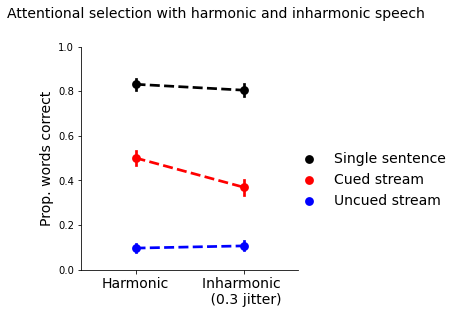

In [454]:
order = ['Harmonic', 'Inharmonic \n (0.3 jitter)']


hues = ['k', 'r', 'b']
hue_order = ['Single sentence', 'Cued stream', 'Uncued stream']
fontsize=14


g = sns.catplot(kind='point',
    data=spch_rslts,
    x='distractor_condition', y='hits',
    hue = 'attended_stream', hue_order=hue_order,
    palette=hues,
    order = order,
#     hue='distractor_condition', hue_order=hue_order, palette=distractor_palette,
#     col='subject',
    seed=1, 
    linestyles='--',
    height=4, ratio=.75,
)


g.set_axis_labels("", "Prop. words correct", size=fontsize)
g.set_xticklabels(rotation=0, size=fontsize)
# g.set_xticklabels(rotation=0, size=fontsize)

# g.set_yticklabels(size=fontsize)

# g.set_titles("{col_name} performance", size=fontsize)
g.legend.set_title("")
# plt.yscale('log')
sns.move_legend(g, title='', 
                loc="center right", bbox_to_anchor=(1.1, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)

plt.ylim(0,1)
# g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle('Attentional selection with harmonic and inharmonic speech', y = 1.1,size=fontsize)
# g.fig.tight_layout()
# plt.savefig(plot_out_dir / 'harmonicity_plot.pdf',  bbox_inches='tight')
# plt.savefig(plot_out_dir / 'harmonicity_plot.svg',  format="svg", bbox_inches='tight')

<a id='corrs'></a>

# Target-mixture correlations by Layer

In [38]:
corr_paths = list(Path('../').glob('*corrs*.pkl'))
skip = 'attn_cue_jsin_multi_distractor_w_audioset_full_SNR_-20_to_20_bs_64_lr_1e-4_corrs'
corr_paths = [path for path in corr_paths if ('noise' not in path.stem) and (path.stem != skip)]

In [39]:
model_dfs = []

for path in corr_paths:
    with open(path, 'rb') as f:
        acts = pickle.load(f)
    for layer in acts['fg_corr_results'].keys():
        df = pd.DataFrame.from_dict({'fg_corrs':acts['fg_corr_results'][layer],
                                 'bg_corrs':acts['bg_corr_results'][layer],
                                 'layer': [layer] * len(acts['fg_corr_results'][layer])})
    #                 'model':[f"{model}"] * len(acts['cue_acts'][layer])}
        df['model'] = path.stem
        model_dfs.append(df)

model_df = pd.concat(model_dfs)


In [40]:
model_df['with_noise'] = model_df.model.str.contains('audioset')

In [41]:

results = pd.melt(model_df, id_vars =['layer','with_noise', 'model'], value_vars=['fg_corrs', 'bg_corrs'], var_name='Stream',
                            value_name="Pearson's r")

In [42]:
results = (results.groupby(["layer", 'Stream', 'with_noise', 'model'])["Pearson's r"]
                     .agg(["mean"])
                     .reset_index())
results = results.rename(columns={'mean':"Pearson's r"})

In [43]:

results['Stream'].replace('fg_corrs','corr(target, mixture)',inplace=True)
results['Stream'].replace('bg_corrs','corr(distractor, mixture)',inplace=True)


In [44]:
layer_order = sorted(results.layer.unique())

/tmp/ipykernel_43133/2664842863.py:19: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(layer_order, rotation=90, fontsize=fontsize-2)


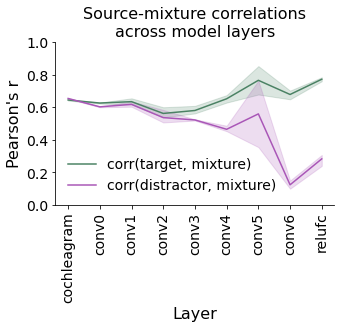

In [46]:

fontsize=16

fig, ax = plt.subplots()
# the size of A4 paper
fig.set_size_inches(5,3)

palette = sns.diverging_palette(145, 300,n=2, s=60, as_cmap=False)

g = sns.lineplot(data=results, x='layer', y="Pearson's r",
              hue = 'Stream', palette=palette,
              hue_order = ['corr(target, mixture)', 'corr(distractor, mixture)'],)
#               order = layer_order,
#               dodge=0.1,
#               ax=ax,
#               height=1, #ratio=2,
#               error='sem')

sns.despine()
g.set_xticklabels(layer_order, rotation=90, fontsize=fontsize-2)

g.set_yticks(np.linspace(0,1,6))
g.set_yticklabels(np.linspace(0,1,6).round(1), fontsize=fontsize-2)

g.set_ylabel("Pearson's r", fontsize=fontsize, )#weight='bold')
g.set_xlabel("Layer", fontsize=fontsize, )#weight='bold')
g.set_title("Source-mixture correlations\nacross model layers", size=fontsize, )#weight='bold')
sns.move_legend(g, title='',
                loc="lower left", 
                frameon=False, fontsize=fontsize-2 )


# plt.savefig(plot_out_dir / 'layer_corrs_green_purple.pdf', bbox_inches='tight')
# plt.savefig(plot_out_dir / 'layer_corrs_green_purple.svg', bbox_inches='tight' ,format="svg")

# plt.tight_layout()

<a id='gains'></a>

## Plost histograms of Attn Gain activations

load data and plot

In [1]:
import pickle
out_file = '../attentional_gain_activations/attn_cue_match_target_speech_and_noise.pkl'

with open(out_file, 'rb') as f:
    acts = pickle.load(f)

import pandas as pd
model_dfs = []
for layer in acts['cue_acts'].keys():
    layer_dict = {'cue_acts': acts['cue_acts'][layer],
                'gain_acts': acts['gain_acts'][layer],
                'layer':[f"{layer}"] * len(acts['cue_acts'][layer])}
#                 'model':[f"{model}"] * len(acts['cue_acts'][layer])}
    layer_df = pd.DataFrame.from_dict(layer_dict)
    model_dfs.append(layer_df)
model_df = pd.concat(model_dfs)


def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def attn_gain(x, bias, slope, threshold):
    return bias + (1-bias) * sigmoid((x - threshold) * slope)
    

def get_sigmoid(acts, layer, n_bins, x=None):
    gain_fn_params = acts['gain_params'][layer]
    cue_acts = acts['cue_acts'][layer]
    
    x_for_fn = x if x is not None else np.linspace(np.abs(cue_acts).min(), np.abs(cue_acts).max(), n_bins)
    bias = gain_fn_params['bias']
    slope = gain_fn_params['slope']
    threshold = gain_fn_params['threshold']
    
    return attn_gain(x_for_fn, bias, slope, threshold).T, x_for_fn
    

    
        

gs_kw = dict(width_ratios=[1, 1, 1], height_ratios=[1, 1, 1, 1])

mosaic = """A12
            .34
            L56
            .78"""
fig, axd = plt.subplot_mosaic(mosaic,
                              figsize=(10, 10), layout="constrained",
                              gridspec_kw=gs_kw)

c_palette = sns.color_palette("magma", 4, as_cmap=False)


n_hist_bins = 100
pad = 8
layer_names = model_df.layer.unique()



gain_demo_layers = [name for name in layer_names if any(key in name for key in ['in', '2','3','6'])]

layer_row_dict = {layer : (str(i), str(i+1)) for layer, i in zip(gain_demo_layers , range(1,9, 2))}

x_min = -1
x_max = 1
# x = np.linspace(x_min,x_max,100)

init_bias = 0
init_slope = 1
init_threshod = 0


layer_names = ['Cochleagram', "Layer 2", "Layer3", "Last Layer"]

layer_name_dict = {df_name:h_name for df_name, h_name in zip(gain_demo_layers, layer_names)}

init_filter = attn_gain(x, init_bias, init_slope, init_threshod)


# axd["A"].plot(x, init_filter, linewidth=2, c='k', ls='--', label='Initialization') # linewidth=4,

fontsize=18

for ix, layer in enumerate(gain_demo_layers):
    gain_filter, input_act_vals = get_sigmoid(acts, layer, n_hist_bins)    
        
    axd["A"].plot(x, gain_filter, linewidth=2, c=c_palette[ix], label=layer_name_dict[layer]) # linewidth=4,
    
    # plot hist of cue activations    
    sns.histplot(data=model_df[model_df.layer == layer], x='cue_acts',
             stat='percent',  log_scale=(False, True), edgecolor='0.1',
#              hue='model', hue_order=hue_order, palette=model_palette,
             color=c_palette[ix], bins=n_hist_bins, ax=axd[layer_row_dict[layer][0]])

    # plot hist of gains
    sns.histplot(data=model_df[model_df.layer == layer], x='gain_acts',
                 stat='percent',  log_scale=(False, True), edgecolor='0.1',
#                  hue='model', hue_order=hue_order, palette=model_palette,
                 color=c_palette[ix], bins=n_hist_bins, ax=axd[layer_row_dict[layer][1]])
    
    axd[layer_row_dict[layer][0]].set_xlabel("Activation", fontsize=fontsize)
    axd[layer_row_dict[layer][0]].set_ylabel("Percent", fontsize=fontsize)

    axd[layer_row_dict[layer][1]].set_xlabel("Gain", fontsize=fontsize)
    axd[layer_row_dict[layer][1]].set_ylabel("Percent", fontsize=fontsize)
    
#     axd[layer_row_dict[layer][0]].set_ylim((10**-3,10**2))
#     axd[layer_row_dict[layer][1]].set_ylim((10**-3,10**2))



axd['1'].set_title("Cue activations pre-gain", fontsize=fontsize)
axd['2'].set_title("Gain activations", fontsize=fontsize)

axd["A"].set_title("Learned gain functions", fontsize=fontsize)
axd["A"].set_ylabel("Gain", fontsize=fontsize)
axd["A"].set_xlabel("Normalized activation", fontsize=fontsize)
axd["A"].set_xticks([x_min, x_max])

axd["A"].set_xticklabels(["min", "max"])
axd["A"].set_ylim(0,1.1)

handles, labels = axd["A"].get_legend_handles_labels()
leg = axd["L"].legend(handles, labels,
                      fontsize=fontsize,
                      frameon=False,
                      loc='center left',
#                       handlelength=0,
#                       markerscale=0,
#                       handletextpad=-1.0,
                      labelcolor= c_palette)
                      #bbox_to_anchor=[-0.05, 0, 1, 1])
leg.get_frame().set_facecolor('none')
leg.get_frame().set_edgecolor('none')
# leg.get_frame().set_linewidth(.3)
axd['L'].axis('off')

# plt.subplots_adjust(hspace=1)


# plt.subplots_adjust(wspace=0.8)
# plt.savefig("../ARO_2023_figs/attn_gains_v2.pdf")

NameError: name 'plt' is not defined